# Electrolyte MD Analysis Demo

Demonstrates the `electrolyte_toolkit` package on a demo binary Lennard-Jones
mixture (a toy electrolyte model: majority "solvent" species, minority "ion"
species). Computes radial distribution function, coordination number, and
diffusion coefficient.

In [1]:
import sys
sys.path.insert(0, "../../src")

import MDAnalysis as mda
import matplotlib.pyplot as plt

from electrolyte_toolkit.rdf import compute_rdf
from electrolyte_toolkit.coordination import coordination_number, first_minimum
from electrolyte_toolkit.diffusion import compute_msd, diffusion_coefficient

Matplotlib is building the font cache; this may take a moment.


In [2]:
u = mda.Universe("dump.electrolyte.lammpstrj", format="LAMMPSDUMP")
print(f"Number of atoms: {len(u.atoms)}")
print(f"Number of frames: {len(u.trajectory)}")
print(f"Atom types: {set(u.atoms.types)}")

Number of atoms: 4000
Number of frames: 201
Atom types: {'1', '2'}


/usr/local/Caskroom/miniforge/base/envs/electrolyte-portfolio/lib/python3.11/site-packages/MDAnalysis/topology/LAMMPSParser.py:670: UserWarning: Guessed all Masses to 1.0
  warnings.warn("Guessed all Masses to 1.0")
/usr/local/Caskroom/miniforge/base/envs/electrolyte-portfolio/lib/python3.11/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


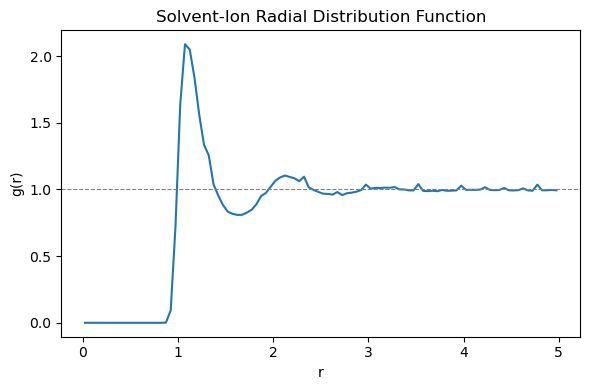

In [3]:
bins, rdf = compute_rdf(u, "type 1", "type 2", nbins=100, range=(0.0, 5.0))

plt.figure(figsize=(6, 4))
plt.plot(bins, rdf)
plt.xlabel("r")
plt.ylabel("g(r)")
plt.title("Solvent-Ion Radial Distribution Function")
plt.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("rdf_plot.png", dpi=150)
plt.show()

In [4]:
box = u.dimensions[:3]
volume = box[0] * box[1] * box[2]
n_type2 = len(u.select_atoms("type 2"))
density_type2 = n_type2 / volume

r_cut = first_minimum(bins, rdf)
cn = coordination_number(bins, rdf, density_type2, r_max=r_cut)

print(f"First minimum (solvation shell cutoff): r = {r_cut:.3f}")
print(f"Coordination number within first shell: {cn:.3f}")

First minimum (solvation shell cutoff): r = 1.625
Coordination number within first shell: 0.965


100%|██████████████████████████████████████████████████████████████████████████████| 371/371 [00:00<00:00, 12758.37it/s]


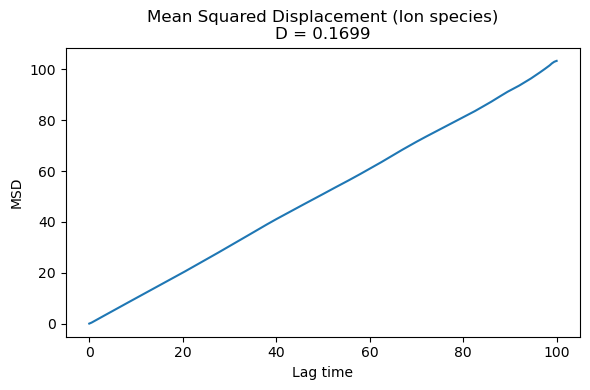

Diffusion coefficient D = 0.1699


In [5]:
u_unwrapped = mda.Universe("dump.electrolyte.unwrapped.lammpstrj", format="LAMMPSDUMP")
msd = compute_msd(u_unwrapped, select="type 2", msd_type="xyz", fft=True)

frame_dt = 0.005 * 100  # timestep * dump frequency
lag_times = [i * frame_dt for i in range(len(msd))]

D = diffusion_coefficient(msd, timestep=frame_dt, dim=3)

plt.figure(figsize=(6, 4))
plt.plot(lag_times, msd)
plt.xlabel("Lag time")
plt.ylabel("MSD")
plt.title(f"Mean Squared Displacement (Ion species)\nD = {D:.4f}")
plt.tight_layout()
plt.savefig("msd_plot.png", dpi=150)
plt.show()

print(f"Diffusion coefficient D = {D:.4f}")

## Summary

- **RDF**: Solvent-ion g(r) peaks at r ≈ 1.1, consistent with the Lennard-Jones
  σ = 1.0 used for this interaction.
- **Coordination number**: ≈ 0.97 ions within the first solvation shell
  (r < 1.625), consistent with the dilute (10%) ion concentration in this
  demo system.
- **Diffusion coefficient**: D ≈ 0.17 (reduced LJ units), in the expected
  range for a moderately dense liquid at this temperature/density.

Next steps: extend this toolkit to realistic electrolyte force fields
(e.g., TIP3P water + Na⁺/Cl⁻ with literature-parameterized pair potentials).